# Detecting Topic Merges and Splits in Dynamic Political Conversations

Cláudia Oliveira 

Supervisor - Prof. Dr. Álvaro Figueira

Faculty of Science, University of Porto

In [ ]:
import pandas as pd
import re
from functions import *
import ast
import os
os.chdir("../..")

In [ ]:
tweets = pd.read_csv("datasets/119congresstweets/cleanedtweets.csv", encoding="utf-8", low_memory=False)
lda = pd.read_csv("datasets/119congresstweets/ldaresults.csv", encoding="utf-8", low_memory=False)
nmf = pd.read_csv("datasets/119congresstweets/nmfresults.csv", encoding="utf-8", low_memory=False)
bertopic = pd.read_csv("datasets/119congresstweets/bertildaresults.csv", encoding="utf-8", low_memory=False)
top2vec = pd.read_csv("datasets/119congresstweets/top2vecresults.csv", encoding="utf-8", low_memory=False)

### LDA

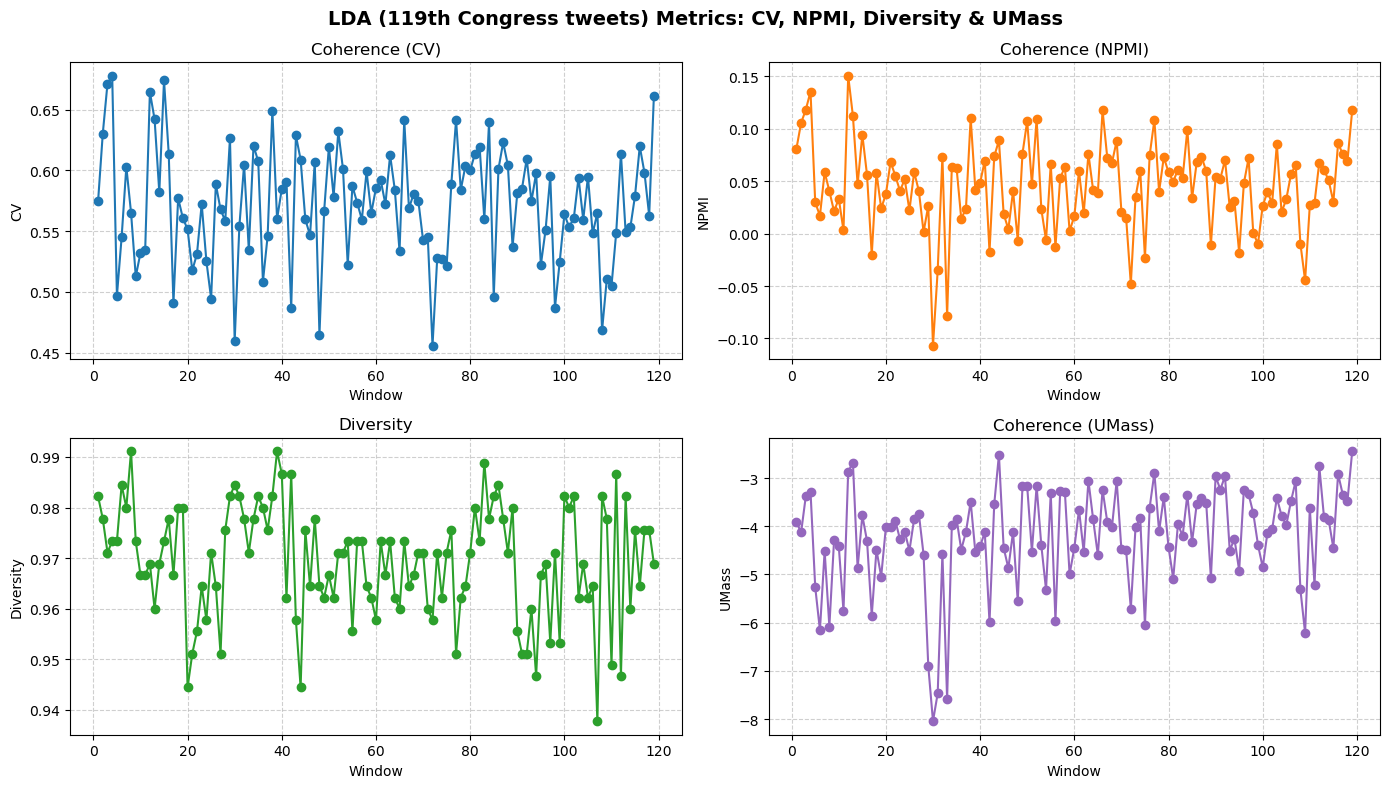

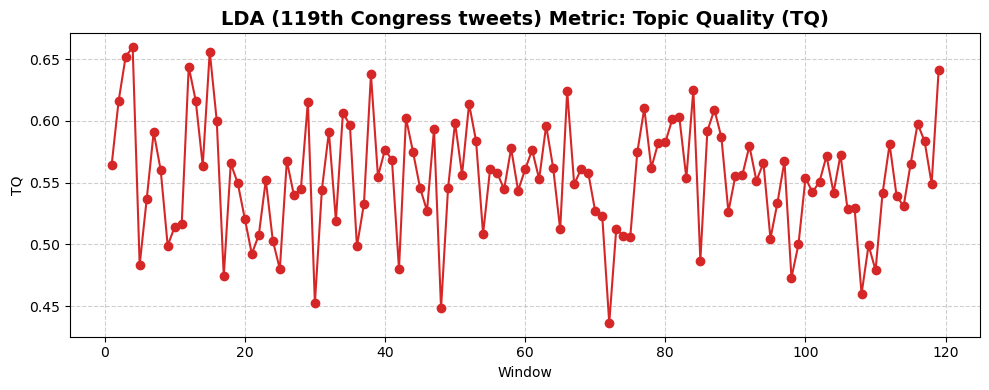

In [3]:
plot_static_metrics(lda, "LDA (119th Congress tweets)")

In [4]:
summarize_static_metrics(lda,"LDA (119th Congress tweets)")

=== LDA (119th Congress tweets) – Overall Metrics Summary ===
CV: mean=0.5716, std=0.0472, p25=0.5449, median=0.5735, p75=0.6035
NPMI: mean=0.0448, std=0.0419, p25=0.0227, median=0.0483, p75=0.0697
UMass: mean=-4.2256, std=1.0432, p25=-4.5380, median=-4.1080, p75=-3.4746
Diversity: mean=0.9694, std=0.0111, p25=0.9622, median=0.9711, p75=0.9778
Topic Quality (TQ): mean=0.5541, std=0.0460, p25=0.5266, median=0.5556, p75=0.5830


### NMF

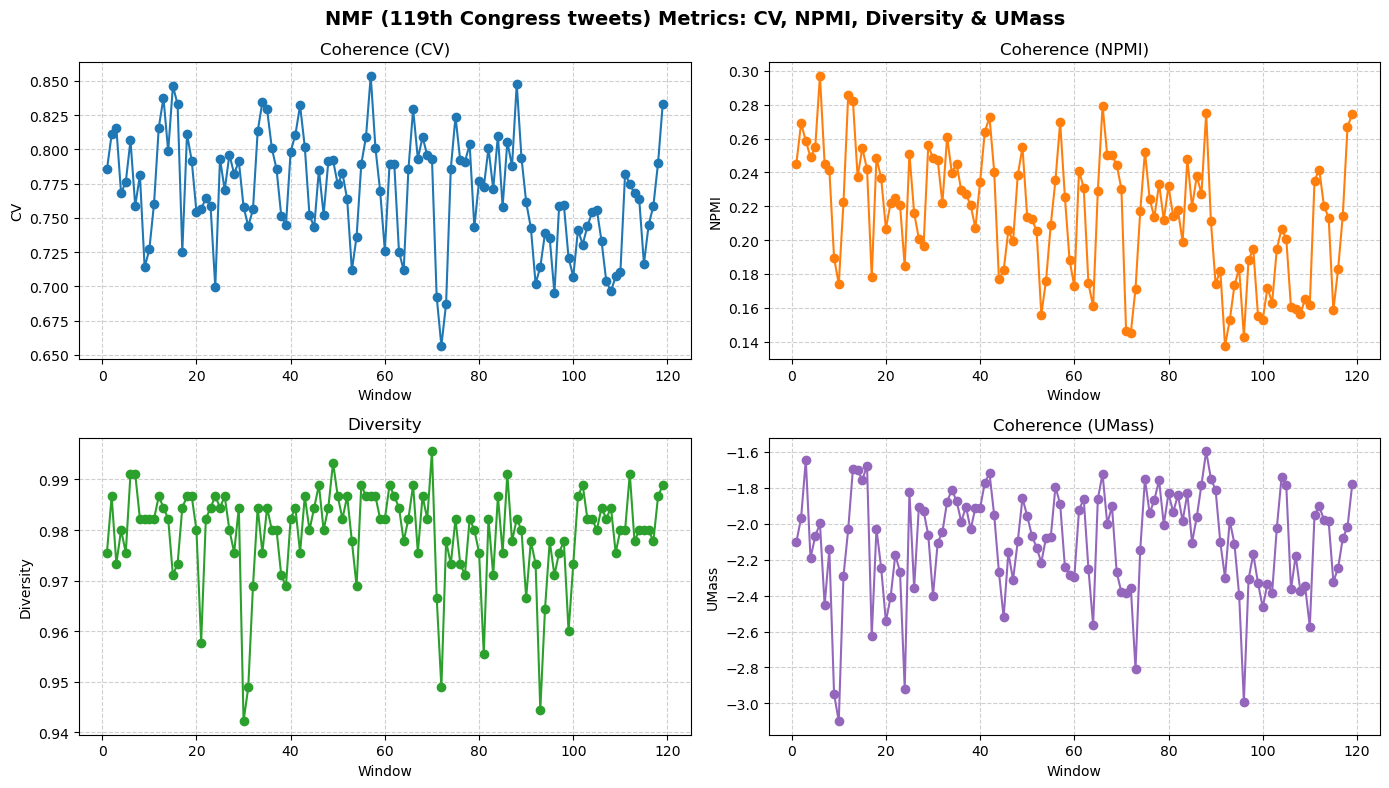

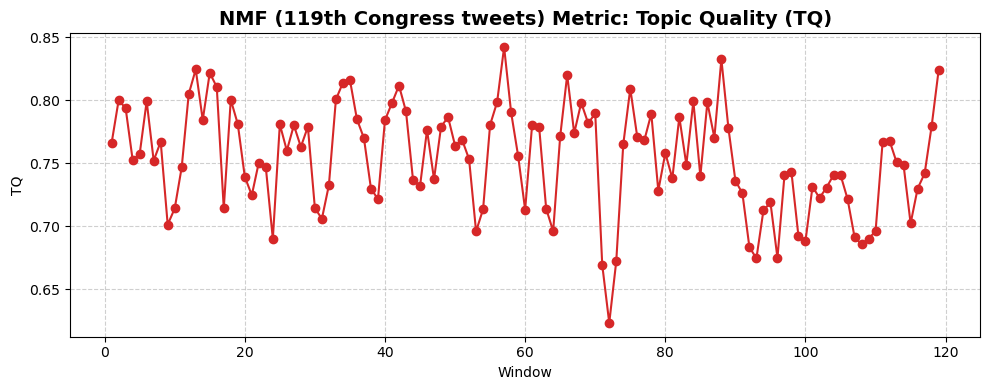

In [5]:
plot_static_metrics(nmf, "NMF (119th Congress tweets)")

In [6]:
summarize_static_metrics(nmf,"NMF (119th Congress tweets)")

=== NMF (119th Congress tweets) – Overall Metrics Summary ===
CV: mean=0.7697, std=0.0399, p25=0.7436, median=0.7724, p75=0.7960
NPMI: mean=0.2155, std=0.0370, p25=0.1839, median=0.2202, p75=0.2432
UMass: mean=-2.1038, std=0.2948, p25=-2.2948, median=-2.0623, p75=-1.8968
Diversity: mean=0.9793, std=0.0094, p25=0.9756, median=0.9822, p75=0.9844
Topic Quality (TQ): mean=0.7539, std=0.0421, p25=0.7254, median=0.7573, p75=0.7843


### BERTopic

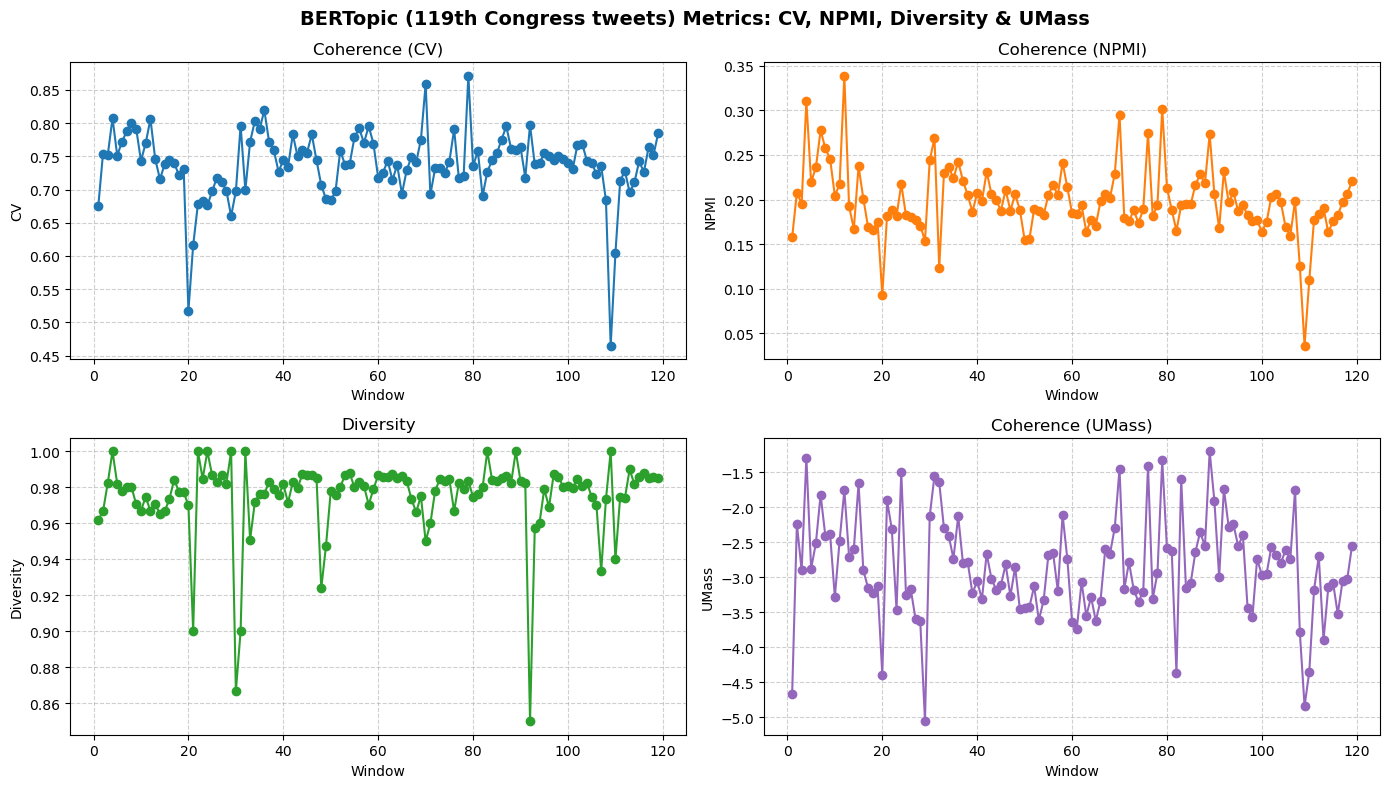

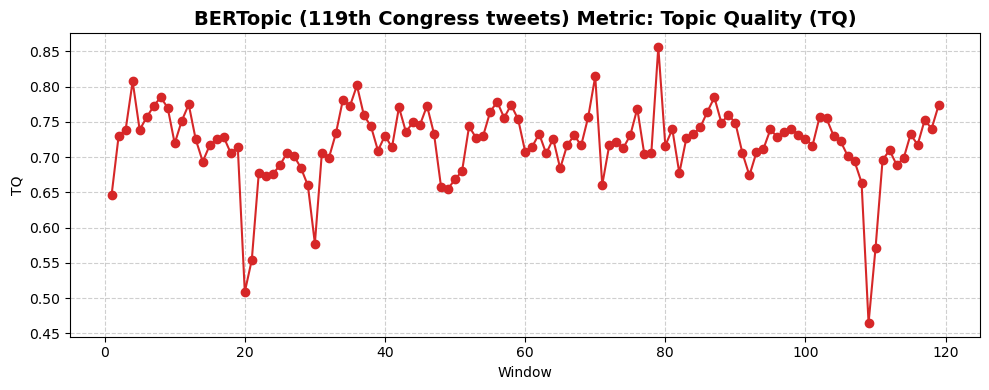

In [3]:
plot_static_metrics(bertopic, "BERTopic (119th Congress tweets)")

In [4]:
summarize_static_metrics(bertopic,"BERTopic (119th Congress tweets)")

=== BERTopic (119th Congress tweets) – Overall Metrics Summary ===
CV: mean=0.7381, std=0.0519, p25=0.7179, median=0.7425, p75=0.7657
NPMI: mean=0.1981, std=0.0398, p25=0.1773, median=0.1942, p75=0.2151
UMass: mean=-2.8489, std=0.7335, p25=-3.2617, median=-2.8758, p75=-2.4454
Diversity: mean=0.9751, std=0.0222, p25=0.9734, median=0.9803, p75=0.9850
Topic Quality (TQ): mean=0.7200, std=0.0533, p25=0.7050, median=0.7269, p75=0.7496


### Top2Vec

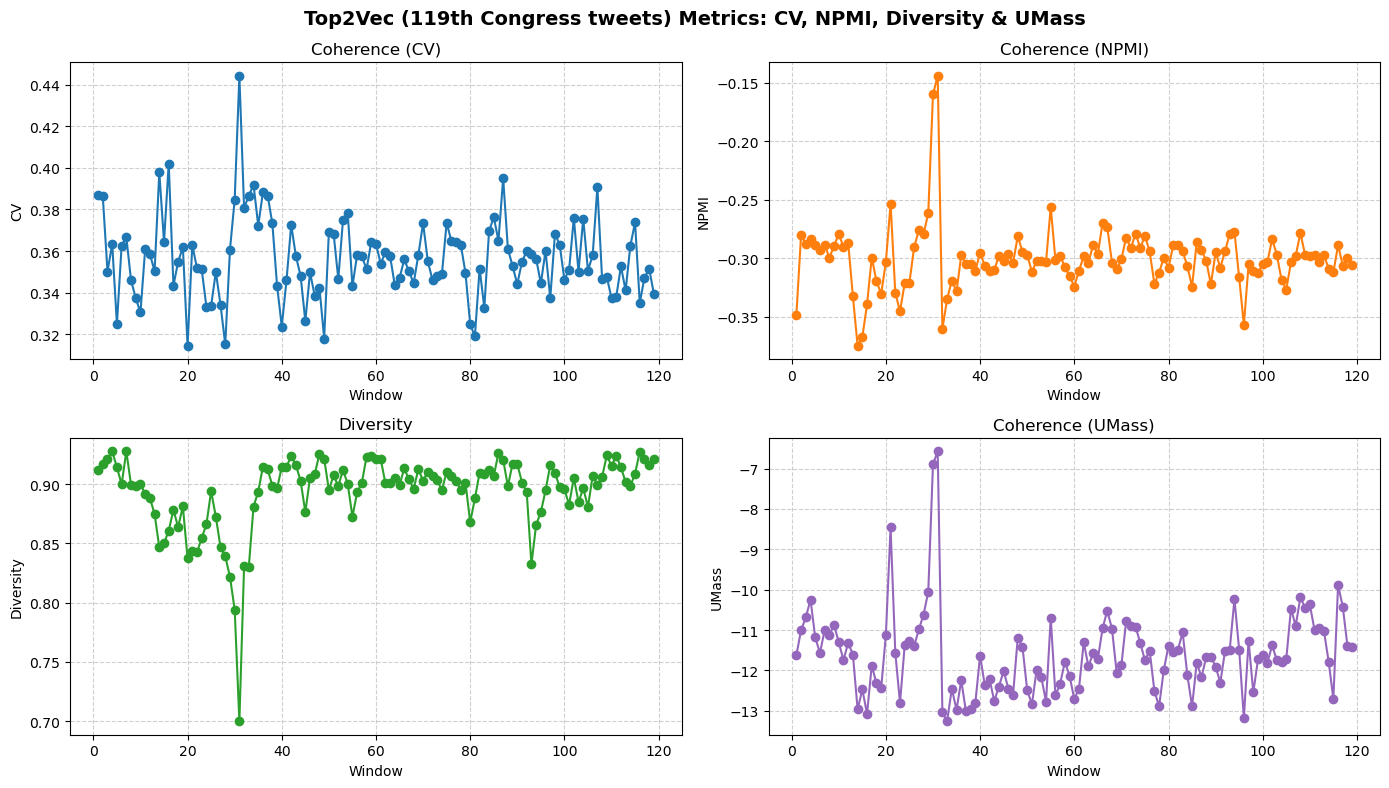

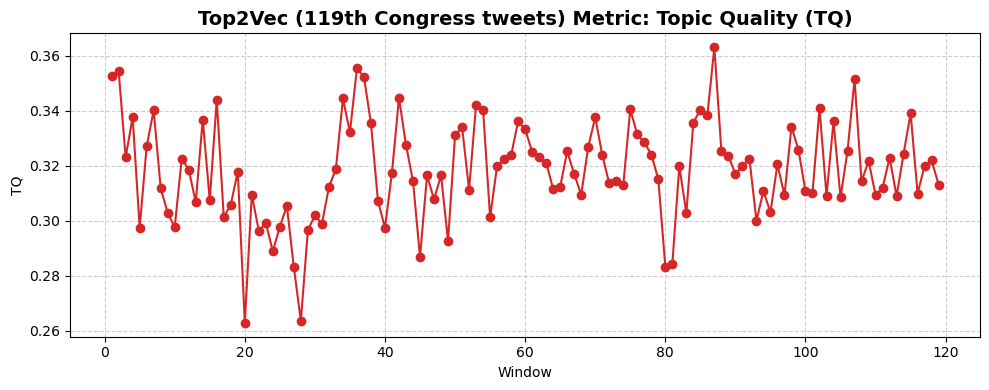

In [9]:
plot_static_metrics(top2vec, "Top2Vec (119th Congress tweets)")

In [10]:
summarize_static_metrics(top2vec,"Top2Vec (119th Congress tweets)")

=== Top2Vec (119th Congress tweets) – Overall Metrics Summary ===
CV: mean=0.3565, std=0.0196, p25=0.3459, median=0.3549, p75=0.3648
NPMI: mean=-0.3005, std=0.0281, p25=-0.3108, median=-0.3009, p75=-0.2900
UMass: mean=-11.5995, std=1.0483, p25=-12.3244, median=-11.6326, p75=-11.0877
Diversity: mean=0.8937, std=0.0316, p25=0.8864, median=0.9012, p75=0.9129
Topic Quality (TQ): mean=0.3184, std=0.0180, p25=0.3087, median=0.3185, p75=0.3298


### UN General

BERTilda

In [ ]:
bertilda = pd.read_csv("datasets/undebates/un_bertilda_quality_scores.csv", encoding="utf-8", low_memory=False)

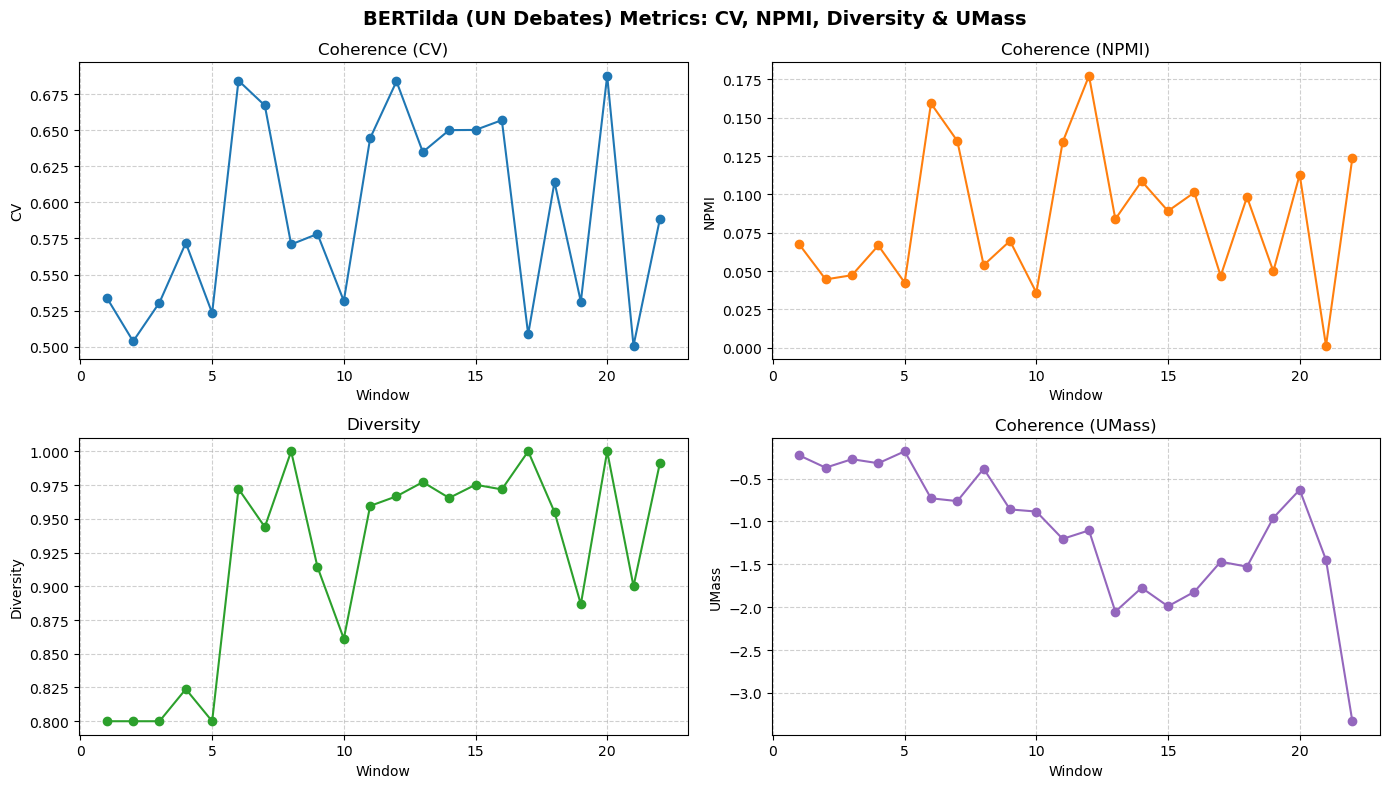

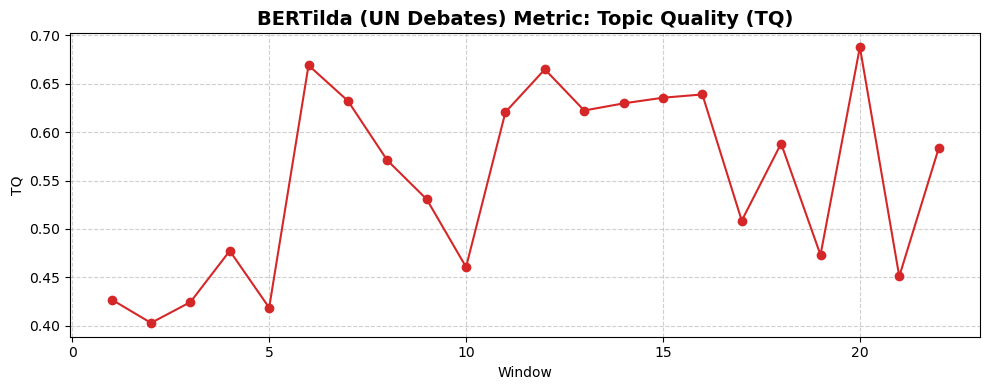

In [3]:
plot_static_metrics(bertilda, "BERTilda (UN Debates)")

In [4]:
summarize_static_metrics(bertilda, "BERTilda (UN Debates)")

=== BERTilda (UN Debates) – Overall Metrics Summary ===
CV: mean=0.5931, std=0.0660, p25=0.5313, median=0.5832, p75=0.6503
NPMI: mean=0.0841, std=0.0442, p25=0.0480, median=0.0768, p75=0.1118
UMass: mean=-1.1051, std=0.7755, p25=-1.5131, median=-0.9215, p75=-0.4458
Diversity: mean=0.9211, std=0.0741, p25=0.8675, median=0.9573, p75=0.9745
Topic Quality (TQ): mean=0.5508, std=0.0948, p25=0.4638, median=0.5770, p75=0.6316


In [5]:
metrics = ["cv", "diversity", "tq"]
drift_table(bertilda, metrics, model_name="BERTilda")

Drift metrics for model BERTilda


,metric,drift,p_value,r2
0,cv,0.001007,0.376481,0.039301
1,diversity,0.003745,0.000915,0.430388
2,tq,0.002988,0.058569,0.167504


Volatility metrics for model BERTilda (window=3)


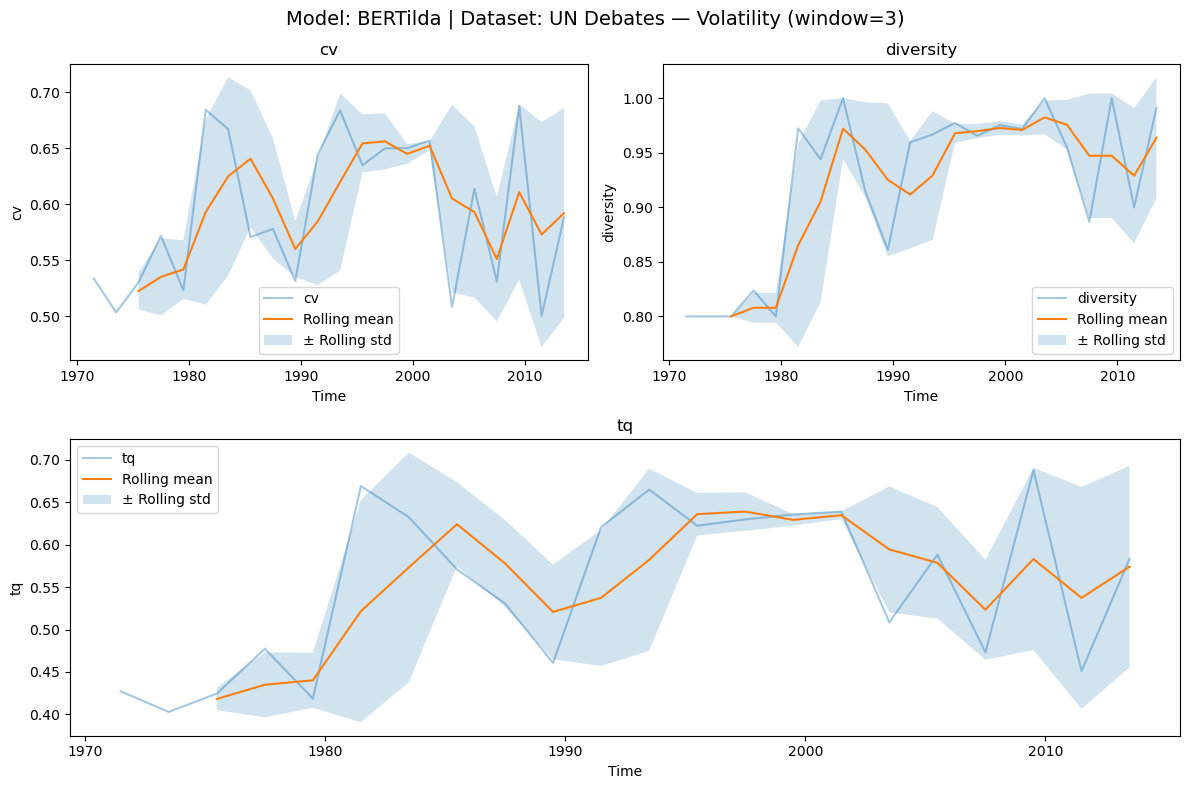

      metric  window  rolling_mean_avg  rolling_std_avg  rolling_std_max
0         cv       3          0.598226         0.053813         0.100443
1  diversity       3          0.925166         0.037962         0.093322
2         tq       3          0.558000         0.065464         0.135208


In [9]:
volatility_df = volatility_table(
    bertilda,
    metrics,
    window=3,
    model_name="BERTilda",
    dataset_name="UN Debates",
    time_col="year",
    start_col="start_year",
    end_col="end_year",
    plot=True
)

print(volatility_df)

Tomotopy DTM


In [ ]:
tomotopy = pd.read_csv("datasets/undebates/un_tomotopydtm_qualityscore.csv", encoding="utf-8", low_memory=False)

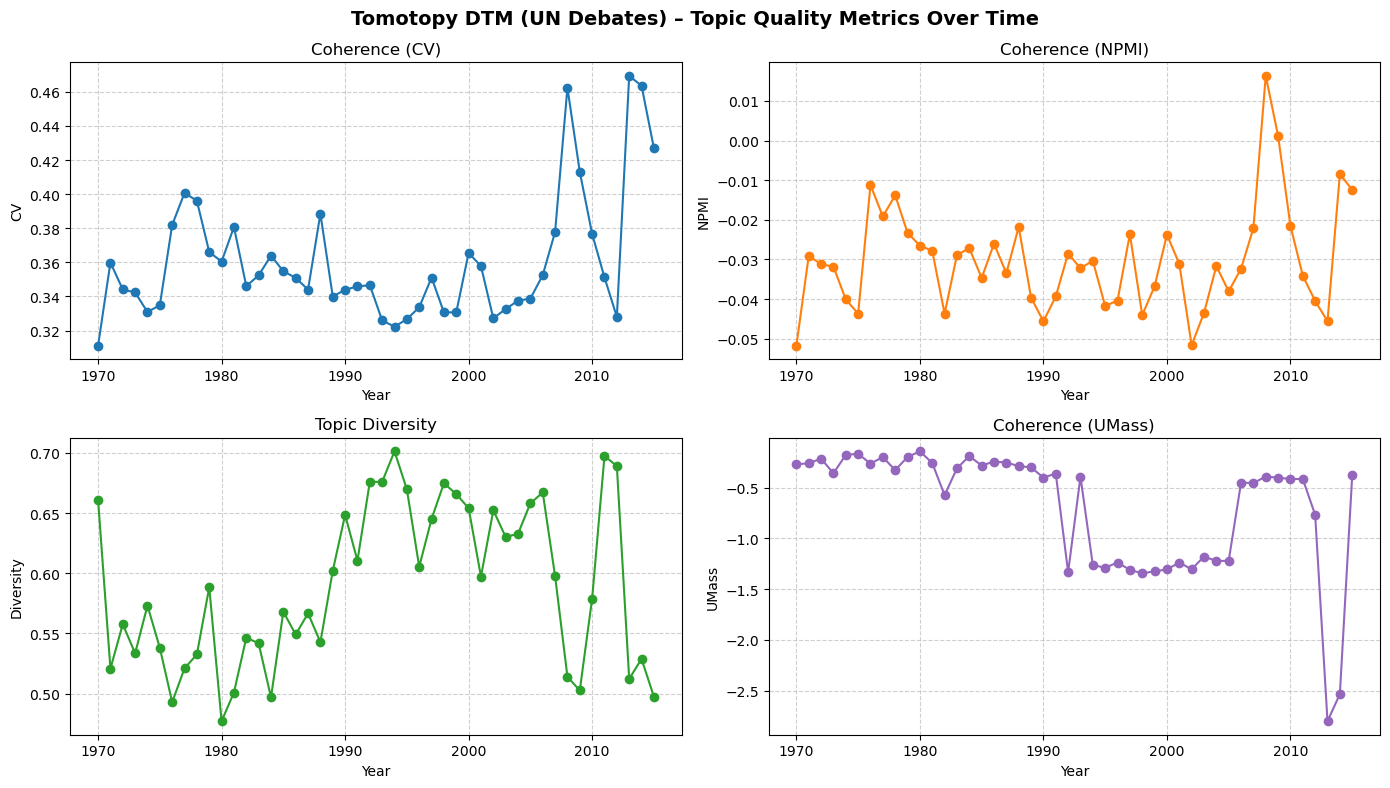

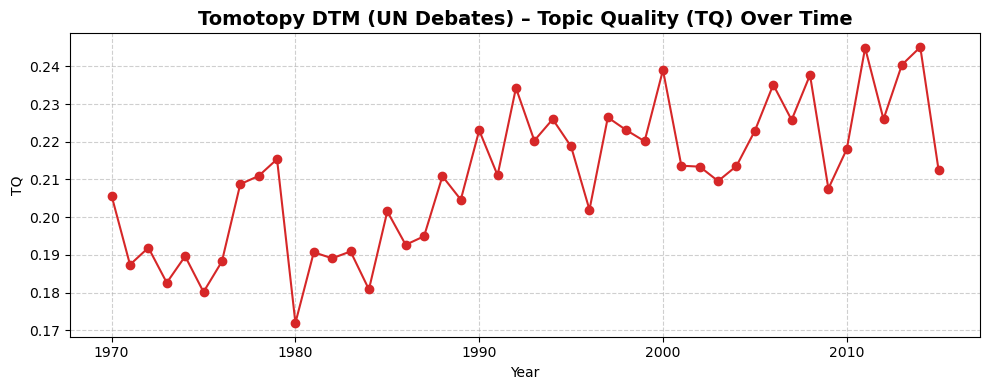

In [16]:
plot_temporal_metrics_tomotopy(tomotopy, "Tomotopy DTM (UN Debates)")
plot_temporal_tq_tomotopy(tomotopy, "Tomotopy DTM (UN Debates)")

In [17]:
summarize_temporal_metrics_tomotopy(tomotopy, "Tomotopy DTM (UN Debates)")

=== Tomotopy DTM (UN Debates) – Temporal Metrics Summary ===
CV: mean=0.3606, std=0.0371, p25=0.3355, median=0.3510, p75=0.3740
NPMI: mean=-0.0302, std=0.0133, p25=-0.0400, median=-0.0315, p75=-0.0236
UMass: mean=-0.6972, std=0.6138, p25=-1.2351, median=-0.3978, p75=-0.2661
Diversity: mean=0.5890, std=0.0670, p25=0.5328, median=0.5837, p75=0.6536
Topic Quality (TQ): mean=0.2109, std=0.0187, p25=0.1932, median=0.2118, p75=0.2231


In [8]:
metrics = ["cv", "diversity", "tq"]
drift_table(tomotopy, metrics, model_name="Tomotopy DTM")

Drift metrics for model Tomotopy DTM


,metric,drift,p_value,r2
0,cv,0.000943,2.040745e-02,0.116249
1,diversity,0.001590,3.099831e-02,0.101428
2,tq,0.001043,2.053220e-09,0.561810


Volatility metrics for model Tomotopy DTM (window=3)


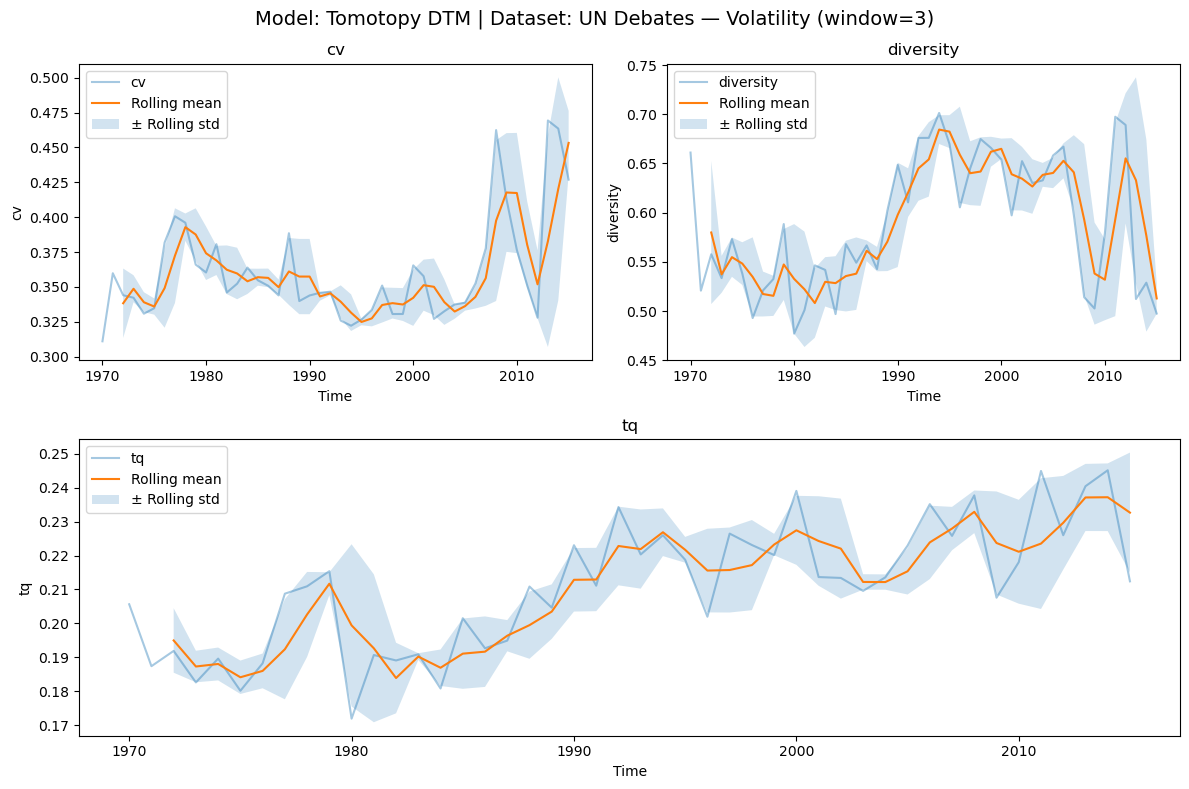

      metric  window  rolling_mean_avg  rolling_std_avg  rolling_std_max
0         cv       3          0.359558         0.019797         0.080005
1  diversity       3          0.590263         0.037128         0.104597
2         tq       3          0.210829         0.009855         0.023908


In [9]:
volatility_df = volatility_table(
    tomotopy,
    metrics,
    window=3,
    model_name="Tomotopy DTM",
    dataset_name="UN Debates",
    time_col="year",
    start_col="start_year",
    end_col="end_year",
    plot=True
)

print(volatility_df)

DETM

In [ ]:
detm = pd.read_csv("datasets/undebates/un_detm_qualityscore.csv", encoding="utf-8", low_memory=False)

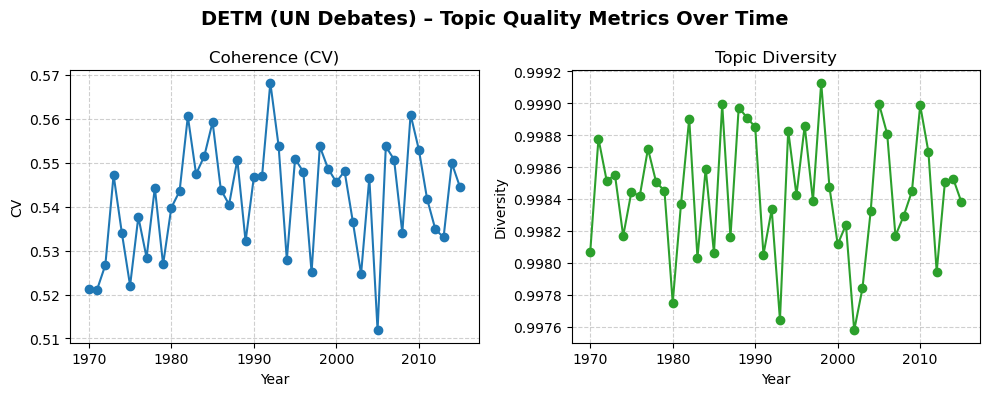

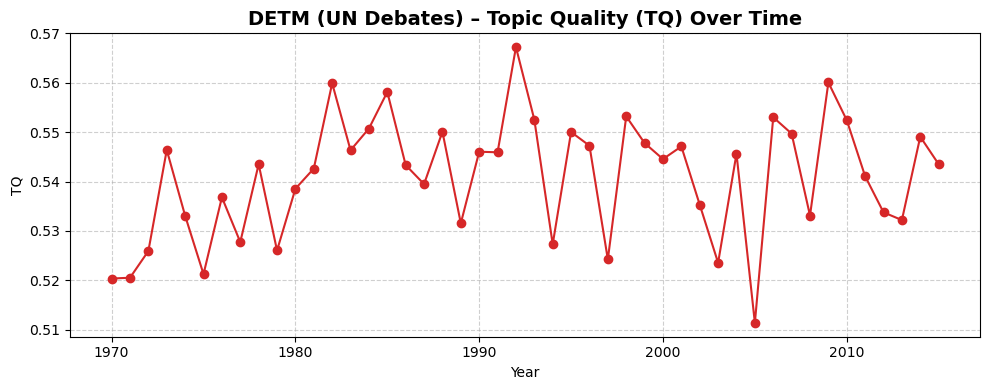

In [20]:
plot_temporal_metrics_detm(detm, "DETM (UN Debates)")
plot_temporal_tq_detm(detm, "DETM (UN Debates)")

In [21]:
summarize_temporal_metrics_detm(detm, "DETM (UN Debates)")

=== DETM (UN Debates) – Temporal Metrics Summary ===
CV: mean=0.5417, std=0.0124, p25=0.5332, median=0.5443, p75=0.5505
Diversity: mean=0.9984, std=0.0004, p25=0.9982, median=0.9984, p75=0.9988
Topic Quality (TQ): mean=0.5408, std=0.0124, p25=0.5324, median=0.5435, p75=0.5495


In [11]:
metrics = ["cv", "diversity", "tq"]
detm['tq'] = detm['topic_quality']
drift_table(detm, metrics, model_name="DETM")

Drift metrics for model DETM


,metric,drift,p_value,r2
0,cv,2.133308e-04,0.121523,0.053619
1,diversity,-1.528597e-07,0.971702,0.000029
2,tq,2.129305e-04,0.121862,0.053524


Volatility metrics for model DETM (window=3)


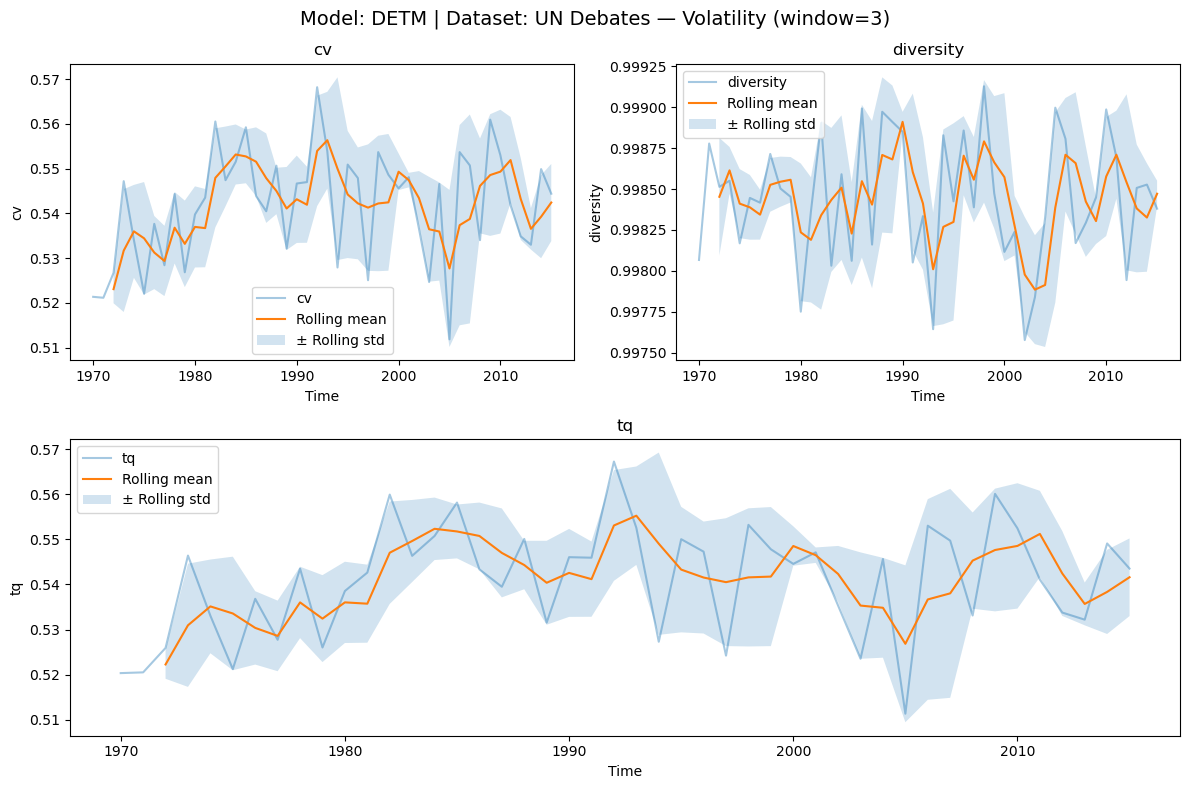

      metric  window  rolling_mean_avg  rolling_std_avg  rolling_std_max
0         cv       3          0.542054         0.010595         0.023335
1  diversity       3          0.998442         0.000349         0.000603
2         tq       3          0.541210         0.010607         0.023162


In [12]:
volatility_df = volatility_table(
    detm,
    metrics,
    window=3,
    model_name="DETM",
    dataset_name="UN Debates",
    time_col="year",
    start_col="start_year",
    end_col="end_year",
    plot=True
)

print(volatility_df)

#### State of Union

Bertilda

In [ ]:
bertilda = pd.read_csv("datasets/stateofunion/stateofunion_bertilda_quality_scores.csv", encoding="utf-8", low_memory=False)

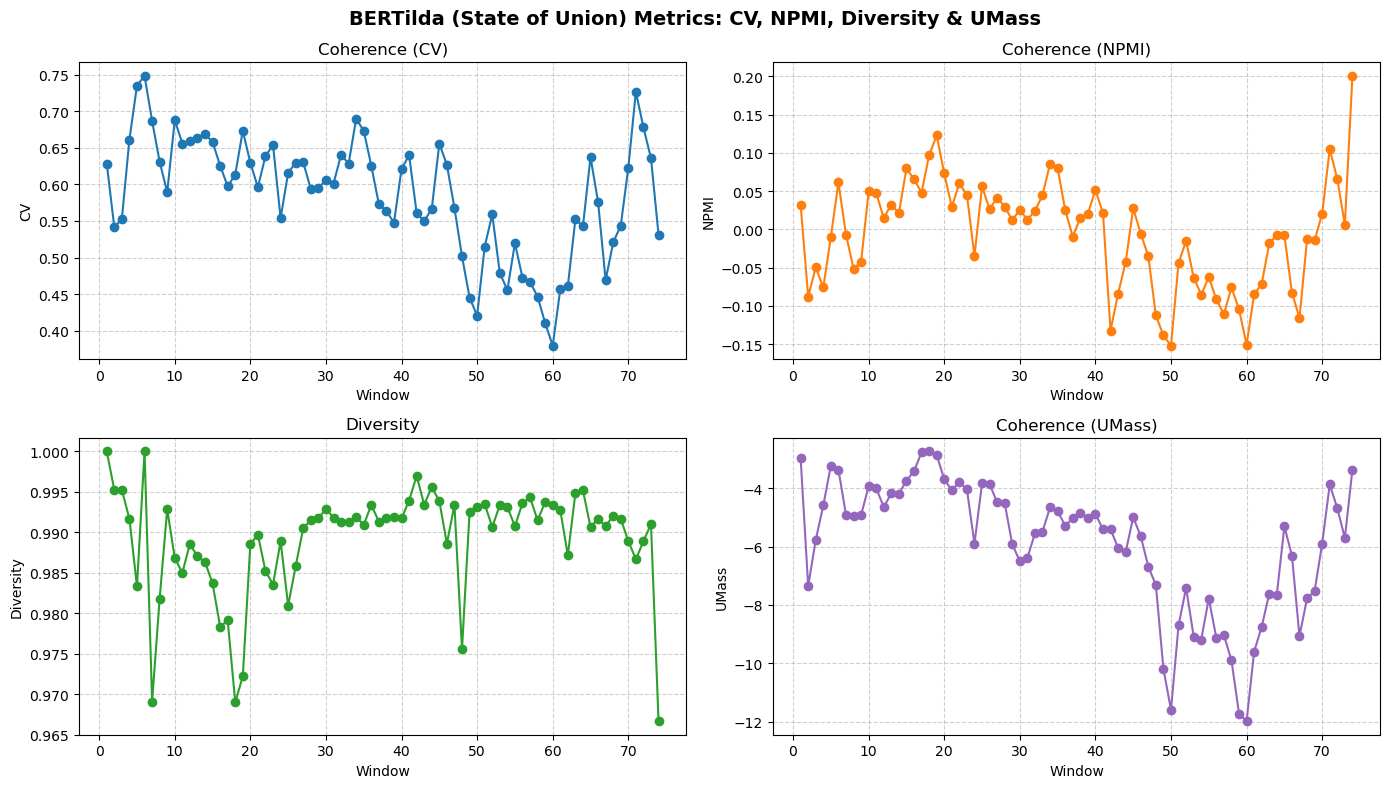

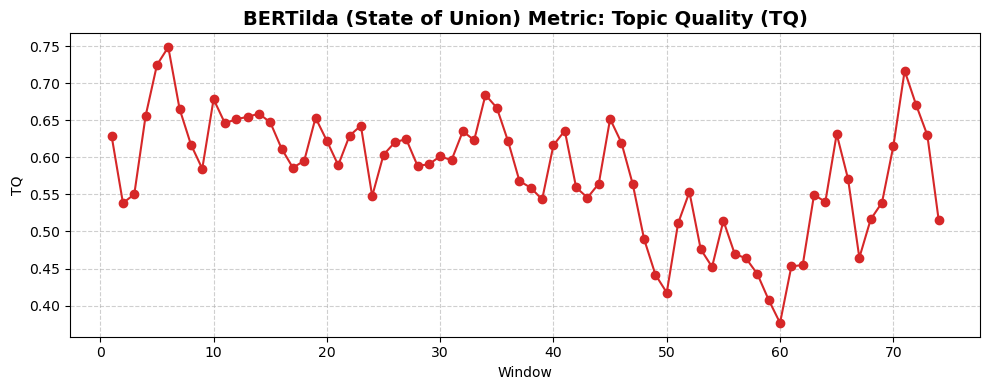

In [11]:
plot_static_metrics(bertilda, "BERTilda (State of Union)")

In [12]:
summarize_static_metrics(bertilda,"BERTilda (State of Union)")

=== BERTilda (State of Union) – Overall Metrics Summary ===
CV: mean=0.5863, std=0.0814, p25=0.5430, median=0.5993, p75=0.6399
NPMI: mean=-0.0056, std=0.0700, p25=-0.0596, median=0.0090, p75=0.0437
UMass: mean=-5.9162, std=2.2599, p25=-7.4002, median=-5.3585, p75=-4.1786
Diversity: mean=0.9893, std=0.0066, p25=0.9870, median=0.9914, p75=0.9933
Topic Quality (TQ): mean=0.5797, std=0.0797, p25=0.5393, median=0.5929, p75=0.6343


In [13]:
metrics = ["cv", "diversity", "tq"]
drift_table(bertilda, metrics, model_name="BERTilda")

Drift metrics for model BERTilda


,metric,drift,p_value,r2
0,cv,-0.000665,0.000001,0.277723
1,diversity,0.000020,0.099900,0.037153
2,tq,-0.000644,0.000002,0.272121


Volatility metrics for model BERTilda (window=3)


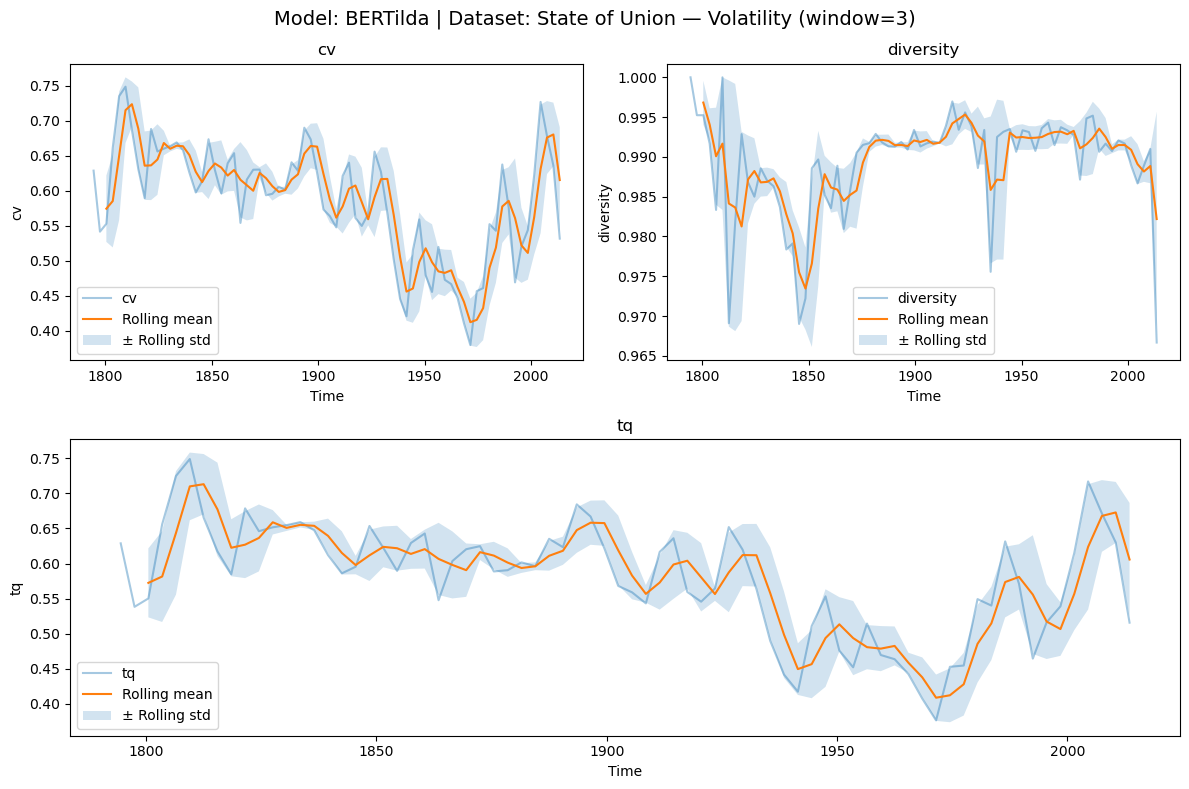

      metric  window  rolling_mean_avg  rolling_std_avg  rolling_std_max
0         cv       3          0.586355         0.039820         0.091979
1  diversity       3          0.989338         0.003438         0.015535
2         tq       3          0.579797         0.039254         0.089234


In [14]:
volatility_df = volatility_table(
    bertilda,
    metrics,
    window=3,
    model_name="BERTilda",
    dataset_name="State of Union",
    time_col="year",
    start_col="start_year",
    end_col="end_year",
    plot=True
)

print(volatility_df)

Tomotopy DTM

In [ ]:
tomotopy = pd.read_csv("datasets/stateofunion/stateofunion_tomotopydtm_qualityscore.csv", encoding="utf-8", low_memory=False)

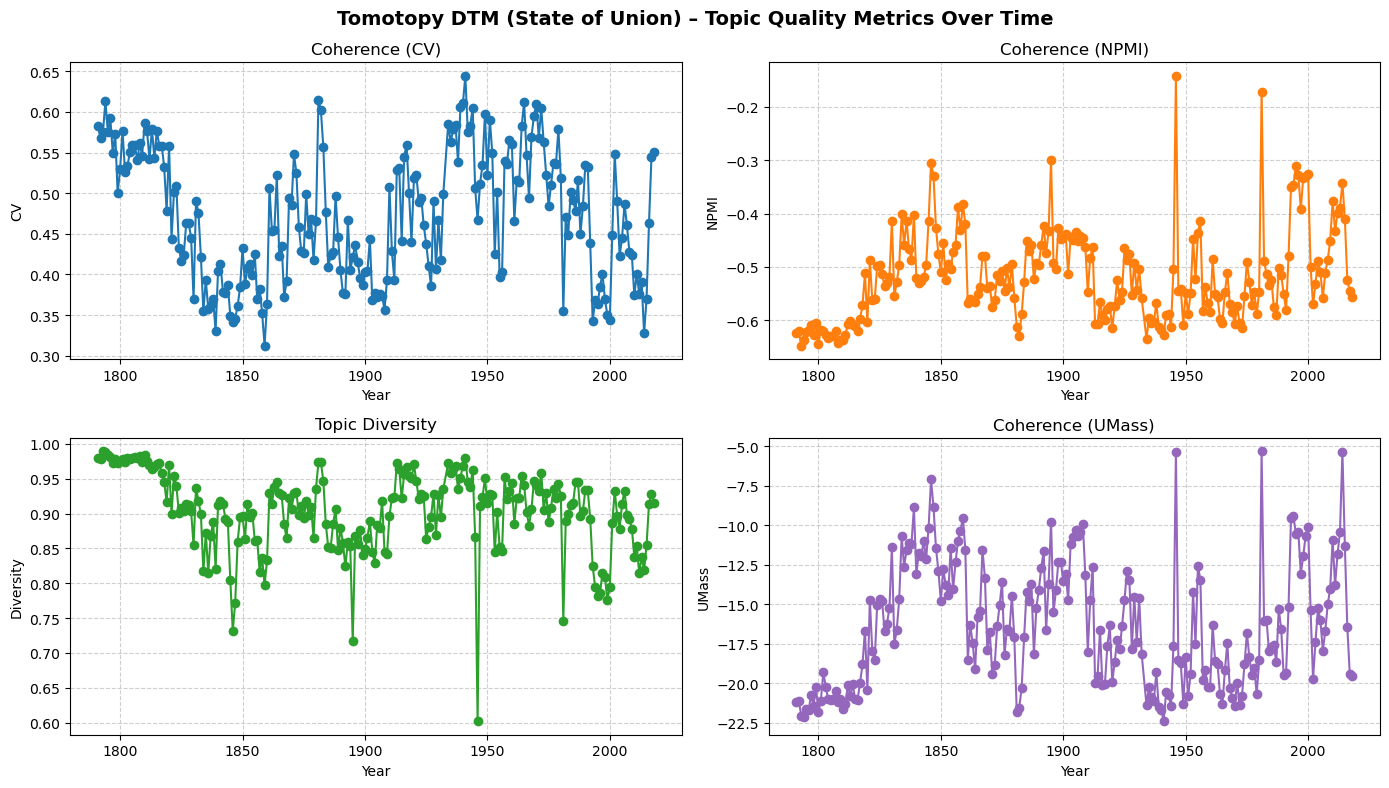

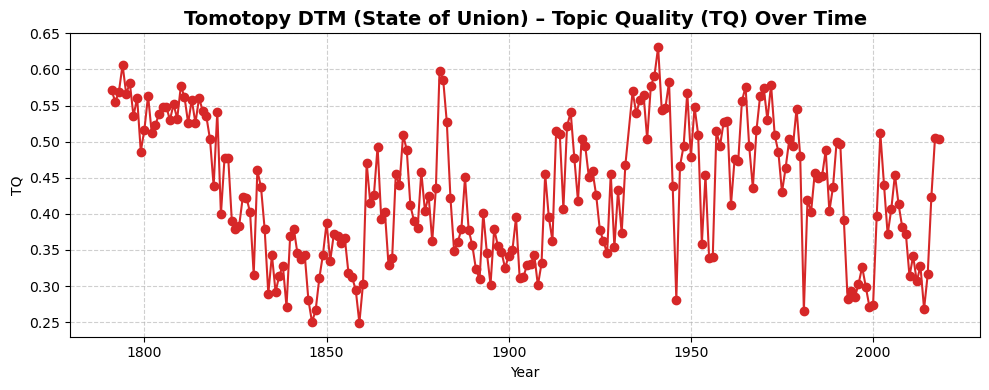

In [28]:
plot_temporal_metrics_tomotopy(tomotopy, "Tomotopy DTM (State of Union)")
plot_temporal_tq_tomotopy(tomotopy, "Tomotopy DTM (State of Union)")

In [29]:
summarize_temporal_metrics_tomotopy(tomotopy, "Tomotopy DTM (State of Union)")

=== Tomotopy DTM (State of Union) – Temporal Metrics Summary ===
CV: mean=0.4731, std=0.0789, p25=0.4045, median=0.4677, p75=0.5411
NPMI: mean=-0.5184, std=0.0855, p25=-0.5833, median=-0.5290, p75=-0.4733
UMass: mean=-16.3443, std=3.9264, p25=-19.8719, median=-16.6974, p75=-13.3845
Diversity: mean=0.9043, std=0.0573, p25=0.8712, median=0.9140, p75=0.9449
Topic Quality (TQ): mean=0.4313, std=0.0935, p25=0.3490, median=0.4267, p75=0.5112


In [17]:
metrics = ["cv", "diversity", "tq"]
drift_table(tomotopy, metrics, model_name="Tomotopy DTM")

Drift metrics for model Tomotopy DTM


,metric,drift,p_value,r2
0,cv,-0.000036,0.654555,0.000891
1,diversity,-0.000228,0.000062,0.068969
2,tq,-0.000146,0.121940,0.010599


Volatility metrics for model Tomotopy DTM (window=3)


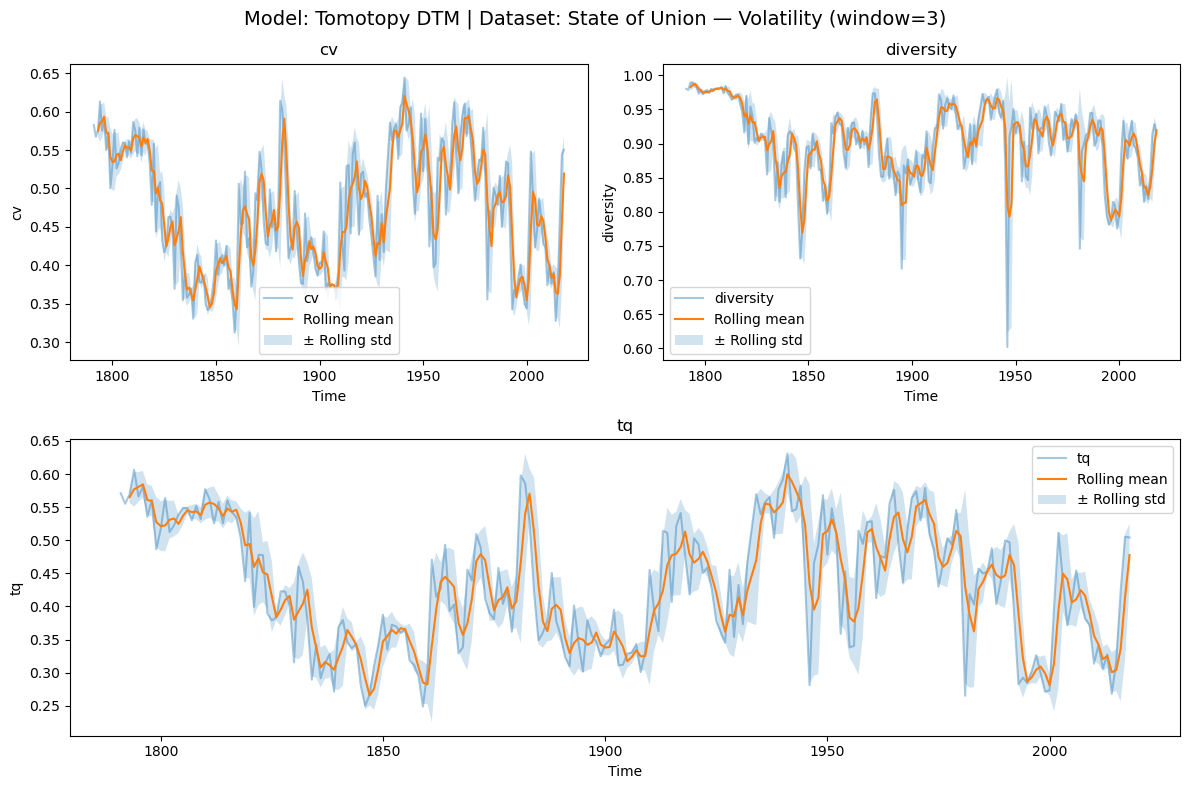

      metric  window  rolling_mean_avg  rolling_std_avg  rolling_std_max
0         cv       3          0.472304         0.035421         0.115503
1  diversity       3          0.903866         0.026472         0.186796
2         tq       3          0.430403         0.042339         0.150781


In [18]:
volatility_df = volatility_table(
    tomotopy,
    metrics,
    window=3,
    model_name="Tomotopy DTM",
    dataset_name="State of Union",
    time_col="year",
    start_col="start_year",
    end_col="end_year",
    plot=True
)

print(volatility_df)

DETM

In [ ]:
detm = pd.read_csv("datasets/stateofunion/stateofunion_detm_qualityscore.csv", encoding="utf-8", low_memory=False)

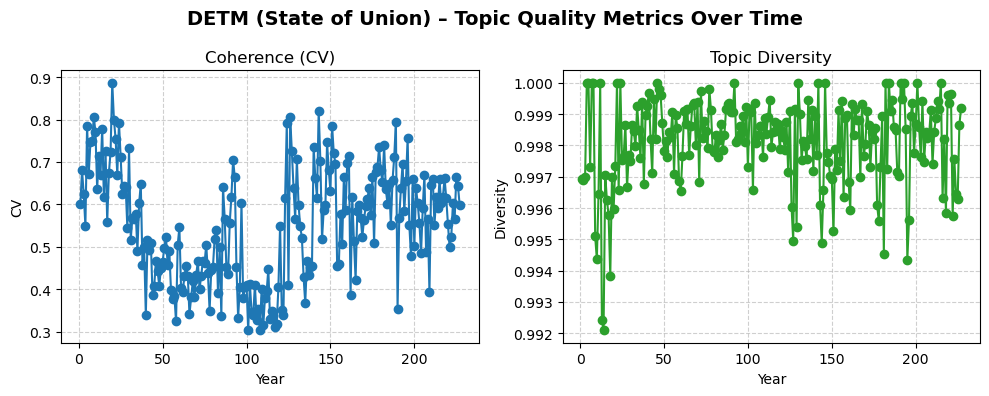

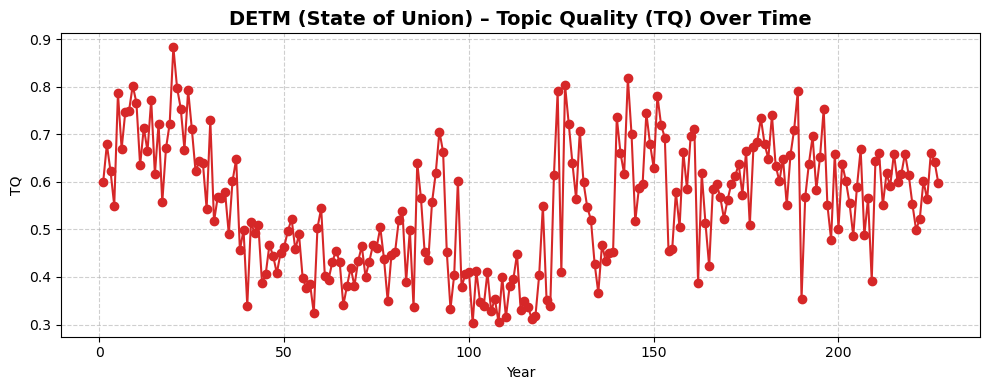

In [32]:
plot_temporal_metrics_detm(detm, "DETM (State of Union)")
plot_temporal_tq_detm(detm, "DETM (State of Union)")

In [33]:
summarize_temporal_metrics_detm(detm, "DETM (State of Union)")

=== DETM (State of Union) – Temporal Metrics Summary ===
CV: mean=0.5499, std=0.1325, p25=0.4413, median=0.5571, p75=0.6507
Diversity: mean=0.9981, std=0.0014, p25=0.9974, median=0.9984, p75=0.9991
Topic Quality (TQ): mean=0.5488, std=0.1319, p25=0.4413, median=0.5566, p75=0.6486


In [20]:
metrics = ["cv", "diversity", "tq"]
detm['tq'] = detm['topic_quality']
drift_table(detm, metrics, model_name="DETM")

Drift metrics for model DETM


,metric,drift,p_value,r2
0,cv,0.000183,0.173257,0.008227
1,diversity,0.000002,0.264990,0.005519
2,tq,0.000184,0.169461,0.008373


Volatility metrics for model DETM (window=3)


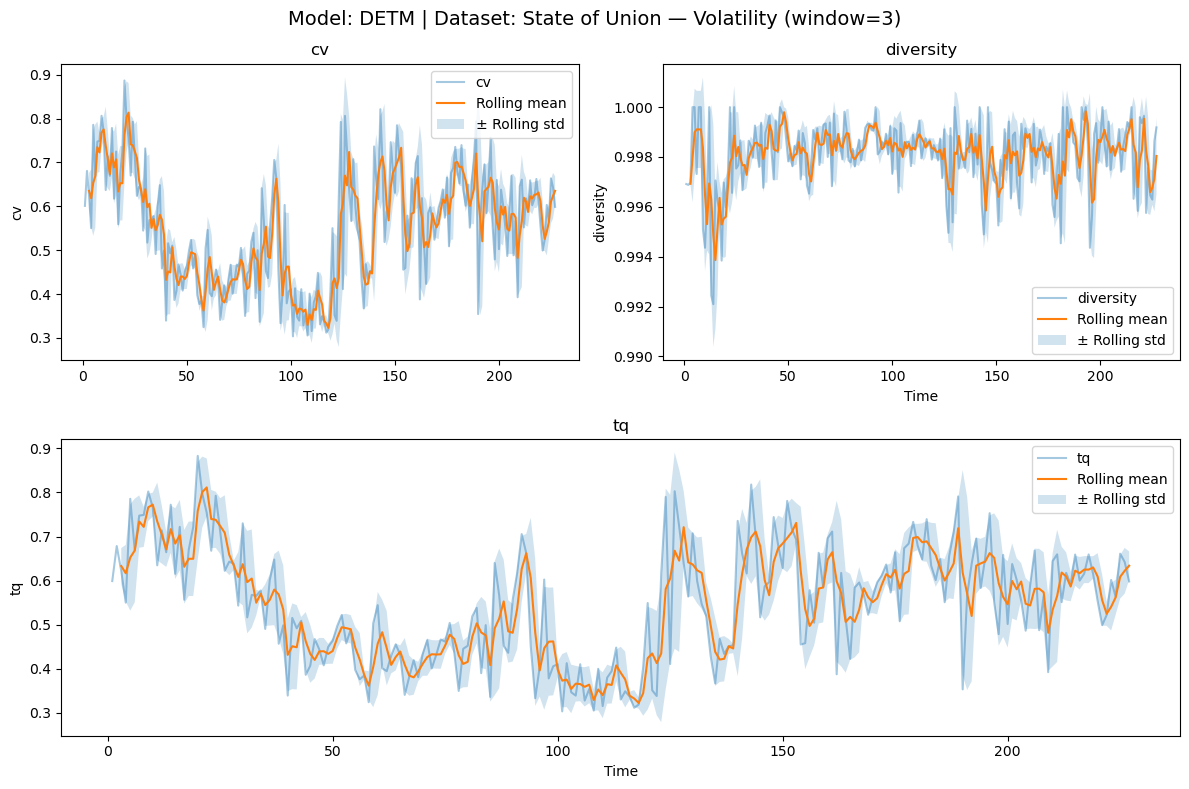

      metric  window  rolling_mean_avg  rolling_std_avg  rolling_std_max
0         cv       3          0.549288         0.070496         0.233219
1  diversity       3          0.998106         0.001069         0.004468
2         tq       3          0.548190         0.070286         0.232769


In [21]:
volatility_df = volatility_table(
    detm,
    metrics,
    window=3,
    model_name="DETM",
    dataset_name="State of Union",
    time_col="year",
    start_col="start_year",
    end_col="end_year",
    plot=True
)

print(volatility_df)